## Import Libraries
Import the Python libraries needed for data manipulation, statistical testing, modelling, and visualisation.

In [13]:
!pip install statsmodels
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load the Dataset
Load the TB burden dataset from the CSV file and inspect the column names to confirm that the required variables are available.

In [14]:
file_path = r"C:\Users\steve\Documents\Datasets\Raw\TB_Burden_Country.csv"
df = pd.read_csv(file_path)

print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['Country or territory name', 'ISO 2-character country/territory code', 'ISO 3-character country/territory code', 'ISO numeric country/territory code', 'Region', 'Year', 'Estimated total population number', 'Estimated prevalence of TB (all forms) per 100 000 population', 'Estimated prevalence of TB (all forms) per 100 000 population, low bound', 'Estimated prevalence of TB (all forms) per 100 000 population, high bound', 'Estimated prevalence of TB (all forms)', 'Estimated prevalence of TB (all forms), low bound', 'Estimated prevalence of TB (all forms), high bound', 'Method to derive prevalence estimates', 'Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population', 'Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound', 'Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, high bound', 'Estimated number of deaths from TB (all forms, excluding HIV)', 'Estimated number of

## Select Relevant Variables
Keep only the variables needed for this analysis and rename the TB prevalence column to simplify the code.

In [15]:
df = df[[
    "Year",
    "Region",
    "Estimated prevalence of TB (all forms) per 100 000 population"
]].copy()

df = df.rename(columns={
    "Estimated prevalence of TB (all forms) per 100 000 population": "TB_Prevalence"
})

## Filter the Data for 2013
Restrict the dataset to observations from the year 2013 and remove missing values from the variables used in the analysis.

In [16]:
df_2013 = df[df["Year"] == 2013].copy()

df_2013 = df_2013.dropna(subset=["Region", "TB_Prevalence"])

## Inspect the Filtered Data
Print the first rows, group counts, and descriptive statistics to confirm the structure of the dataset and understand the distribution of observations across regions.

In [17]:
print("\nFirst few rows:")
print(df_2013.head())

print("\nNumber of observations per region:")
print(df_2013["Region"].value_counts())

print("\nSummary statistics by region:")
print(df_2013.groupby("Region")["TB_Prevalence"].describe())


First few rows:
     Year Region  TB_Prevalence
23   2013    EMR          340.0
47   2013    EUR           27.0
71   2013    AFR          126.0
95   2013    WPR            9.4
119  2013    EUR            8.2

Number of observations per region:
Region
EUR    54
AFR    47
AMR    47
WPR    36
EMR    22
SEA    11
Name: count, dtype: int64

Summary statistics by region:
        count        mean         std   min      25%    50%     75%    max
Region                                                                    
AFR      47.0  291.127660  204.885187  32.0  131.000  215.0  422.50  945.0
AMR      47.0   41.694894   53.211539   0.0    7.350   20.0   54.00  254.0
EMR      22.0  134.495455  221.778924   2.7   20.250   35.0  117.00  906.0
EUR      54.0   50.905556   62.848790   1.9    8.625   20.5   81.00  245.0
SEA      11.0  310.181818  222.484524  57.0  172.500  211.0  437.50  802.0
WPR      36.0  163.097222  199.695485   0.0   23.000   88.5  220.25  748.0


## Visualise TB Prevalence by Region
Create a boxplot to compare the distribution of TB prevalence across regions in 2013.

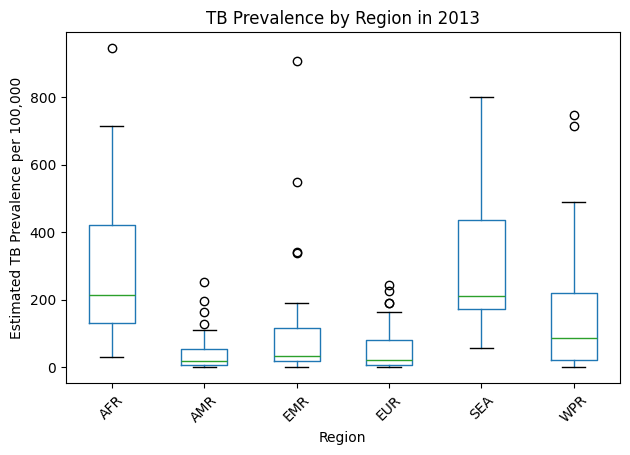

In [18]:
df_2013.boxplot(column="TB_Prevalence", by="Region", grid=False)
plt.title("TB Prevalence by Region in 2013")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Estimated TB Prevalence per 100,000")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Check ANOVA Assumptions
Test the assumptions of normality and homogeneity of variance before performing the ANOVA.

In [19]:
print("\nShapiro-Wilk normality test by region:")
for region in df_2013["Region"].unique():
    region_data = df_2013[df_2013["Region"] == region]["TB_Prevalence"]
    
    if len(region_data) >= 3:
        stat, p = stats.shapiro(region_data)
        print(f"{region}: W={stat:.4f}, p={p:.4f}")
    else:
        print(f"{region}: Not enough observations for Shapiro-Wilk test")

groups = [
    df_2013[df_2013["Region"] == region]["TB_Prevalence"]
    for region in df_2013["Region"].unique()
]

levene_stat, levene_p = stats.levene(*groups)
print(f"\nLevene's test: statistic={levene_stat:.4f}, p={levene_p:.4f}")


Shapiro-Wilk normality test by region:
EMR: W=0.6218, p=0.0000
EUR: W=0.7427, p=0.0000
AFR: W=0.9110, p=0.0016
WPR: W=0.7566, p=0.0000
AMR: W=0.7299, p=0.0000
SEA: W=0.9008, p=0.1892

Levene's test: statistic=7.5711, p=0.0000


## Perform the One-Way ANOVA
Fit a one-way ANOVA model to test whether mean TB prevalence differs significantly across regions.

In [20]:
model = ols("TB_Prevalence ~ C(Region)", data=df_2013).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nANOVA table:")
print(anova_table)


ANOVA table:
                 sum_sq     df          F        PR(>F)
C(Region)  2.294460e+06    5.0  18.641152  2.510333e-15
Residual   5.194219e+06  211.0        NaN           NaN


## Conduct Post-Hoc Testing
Use Tukey’s HSD test to identify which specific regional pairs differ significantly.

In [21]:
tukey = pairwise_tukeyhsd(
    endog=df_2013["TB_Prevalence"],
    groups=df_2013["Region"],
    alpha=0.05
)

print("\nTukey HSD results:")
print(tukey)


Tukey HSD results:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   AFR    AMR -249.4328    0.0 -342.5196  -156.346   True
   AFR    EMR -156.6322  0.002 -273.2021  -40.0623   True
   AFR    EUR -240.2221    0.0 -330.2417 -150.2025   True
   AFR    SEA   19.0542 0.9992 -132.0898  170.1981  False
   AFR    WPR -128.0304 0.0039 -227.9754  -28.0855   True
   AMR    EMR   92.8006 0.2029  -23.7693  209.3704  False
   AMR    EUR    9.2107 0.9997  -80.8089   99.2302  False
   AMR    SEA  268.4869    0.0   117.343  419.6309   True
   AMR    WPR  121.4023 0.0076   21.4574  221.3473   True
   EMR    EUR  -83.5899  0.288 -197.7254   30.5456  False
   EMR    SEA  175.6864 0.0322    9.0494  342.3233   True
   EMR    WPR   28.6018 0.9847  -93.5145   150.718  False
   EUR    SEA  259.2763    0.0  110.0018  408.5507   True
   EUR    WPR  112.1917 0.0132   15.0971  209.2863  

## Compare Regional Means
Calculate and display the mean TB prevalence for each region to support interpretation of the ANOVA results.

In [22]:
print("\nMean TB prevalence by region:")
print(df_2013.groupby("Region")["TB_Prevalence"].mean().sort_values(ascending=False))


Mean TB prevalence by region:
Region
SEA    310.181818
AFR    291.127660
WPR    163.097222
EMR    134.495455
EUR     50.905556
AMR     41.694894
Name: TB_Prevalence, dtype: float64


## Interpret the Results
Use the ANOVA p-value to determine whether there is evidence of statistically significant regional differences in TB prevalence.

In [23]:
p_value = anova_table.loc["C(Region)", "PR(>F)"]

if p_value < 0.05:
    print("\nResult: There is a statistically significant difference in mean TB prevalence across regions in 2013.")
else:
    print("\nResult: There is no statistically significant difference in mean TB prevalence across regions in 2013.")


Result: There is a statistically significant difference in mean TB prevalence across regions in 2013.
